# EDA — Prix au m² des appartements à Paris
**Dataset** : DVF (Demandes de Valeurs Foncières)  
**Objectif** : Explorer les données brutes, filtrer les appartements parisiens et analyser la distribution du prix au m².

## 1. Chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/dvf.csv", low_memory=False)

print("Shape :", df.shape)

Shape : (420066, 41)


In [2]:
print("Colonnes :")
print(df.columns.tolist())

Colonnes :
['id_mutation', 'date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_suffixe', 'adresse_nom_voie', 'adresse_code_voie', 'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'ancien_code_commune', 'ancien_nom_commune', 'id_parcelle', 'ancien_id_parcelle', 'numero_volume', 'lot1_numero', 'lot1_surface_carrez', 'lot2_numero', 'lot2_surface_carrez', 'lot3_numero', 'lot3_surface_carrez', 'lot4_numero', 'lot4_surface_carrez', 'lot5_numero', 'lot5_surface_carrez', 'nombre_lots', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'code_nature_culture', 'nature_culture', 'code_nature_culture_speciale', 'nature_culture_speciale', 'surface_terrain', 'longitude', 'latitude', 'section_prefixe']


In [3]:
df.head()

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,section_prefixe
0,2023-1323349,2023-01-23,1,Vente,709000.00,39,NaN,RUE DE TURENNE,9506,75003,...,42.00,2,NaN,NaN,NaN,NaN,NaN,2.3638540,48.8571580,000AN
1,2023-1323349,2023-01-23,1,Vente,709000.00,39,NaN,RUE DE TURENNE,9506,75003,...,NaN,0,NaN,NaN,NaN,NaN,NaN,2.3638540,48.8571580,000AN
2,2023-1323350,2023-01-27,1,Vente,539080.00,183,NaN,RUE CHAMPIONNET,1723,75018,...,55.00,3,NaN,NaN,NaN,NaN,NaN,2.3338170,48.8942430,000AG
3,2023-1323351,2023-01-23,1,Vente,34000.00,21,B,RUE JEAN LECLAIRE,4907,75017,...,NaN,0,NaN,NaN,NaN,NaN,NaN,2.3256550,48.8948630,000DN
4,2023-1323352,2023-02-09,1,Vente,15000.00,115,B,RUE DES PYRENEES,7904,75020,...,NaN,0,NaN,NaN,NaN,NaN,NaN,2.4044070,48.8564930,000CY


In [4]:
print("Types des colonnes :")
print(df.dtypes)

Types des colonnes :
id_mutation                     object
date_mutation                   object
numero_disposition              object
nature_mutation                 object
valeur_fonciere                 object
adresse_numero                  object
adresse_suffixe                 object
adresse_nom_voie                object
adresse_code_voie               object
code_postal                     object
code_commune                    object
nom_commune                     object
code_departement                object
ancien_code_commune             object
ancien_nom_commune              object
id_parcelle                     object
ancien_id_parcelle              object
numero_volume                   object
lot1_numero                     object
lot1_surface_carrez             object
lot2_numero                     object
lot2_surface_carrez             object
lot3_numero                     object
lot3_surface_carrez             object
lot4_numero                     object
lot4

In [5]:
print("Valeurs manquantes (top 15) :")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))

Valeurs manquantes (top 15) :
ancien_id_parcelle              420058
ancien_code_commune             420058
ancien_nom_commune              420058
nature_culture_speciale         419804
code_nature_culture_speciale    419804
lot5_surface_carrez             419626
lot4_surface_carrez             418928
numero_volume                   418551
lot5_numero                     415536
lot3_surface_carrez             415336
lot4_numero                     409335
adresse_suffixe                 401835
lot3_numero                     390638
surface_terrain                 377661
code_nature_culture             377005
dtype: int64


## 2. Conversion des types

In [6]:
df["valeur_fonciere"] = pd.to_numeric(df["valeur_fonciere"], errors="coerce")
df["surface_reelle_bati"] = pd.to_numeric(df["surface_reelle_bati"], errors="coerce")
df["code_departement"] = pd.to_numeric(df["code_departement"], errors="coerce")
df["nombre_pieces_principales"] = pd.to_numeric(df["nombre_pieces_principales"], errors="coerce")

## 3. Filtrage — Appartements vendus à Paris

In [7]:
df_paris = df[
    (df["nature_mutation"] == "Vente") &
    (df["code_departement"] == 75) &
    (df["type_local"] == "Appartement") &
    (df["valeur_fonciere"] > 0) &
    (df["surface_reelle_bati"] > 0)
].copy()

print("Lignes après filtrage :", df_paris.shape[0])

Lignes après filtrage : 188426


## 4. Création de la variable cible : prix_m2

In [8]:
df_paris["prix_m2"] = df_paris["valeur_fonciere"] / df_paris["surface_reelle_bati"]

## 5. Nettoyage des valeurs extrêmes

In [9]:
df_clean = df_paris[(df_paris["prix_m2"] >= 3000) & (df_paris["prix_m2"] <= 25000)].copy()

print("Lignes après suppression des outliers :", df_clean.shape[0])
print("Lignes supprimées :", df_paris.shape[0] - df_clean.shape[0])

Lignes après suppression des outliers : 156077
Lignes supprimées : 32349


## 6. Statistiques descriptives

In [10]:
print("Nombre de transactions après filtrage :", df_clean.shape[0])
print("Prix m² moyen :", round(df_clean["prix_m2"].mean(), 0), "€/m²")
print("Prix m² médian :", round(df_clean["prix_m2"].median(), 0), "€/m²")
print()
print(df_clean["prix_m2"].describe().round(0))

Nombre de transactions après filtrage : 156077
Prix m² moyen : 10771.0 €/m²
Prix m² médian : 10300.0 €/m²

count    156077.0
mean      10771.0
std        3386.0
min        3000.0
25%        8667.0
50%       10300.0
75%       12179.0
max       25000.0
Name: prix_m2, dtype: float64


In [11]:
by_cp = df_clean.groupby("code_postal").agg(
    prix_m2_median=("prix_m2", "median"),
    nb_ventes=("prix_m2", "count"),
    surface_moyenne=("surface_reelle_bati", "mean")
).round(0).sort_values("prix_m2_median", ascending=False)

print("Prix m² médian, nombre de ventes et surface moyenne par code postal :")
print(by_cp.to_string())

Prix m² médian, nombre de ventes et surface moyenne par code postal :
             prix_m2_median  nb_ventes  surface_moyenne
code_postal                                            
75006               14646.0       3644             63.0
75007               14483.0       4285             77.0
75004               12933.0       2521             54.0
75001               12700.0       1358             57.0
75008               12304.0       2940             82.0
75005               12301.0       4366             49.0
75003               12102.0       2920             50.0
75002               11622.0       1988             46.0
75016               11462.0      13841             83.0
75009               11143.0       5617             54.0
75017               10641.0      12633             56.0
75011               10550.0      14403             44.0
75015               10183.0      17986             51.0
75014               10106.0       8947             47.0
75010                9846.0       

In [12]:
corr_cols = ["surface_reelle_bati", "nombre_pieces_principales", "prix_m2"]
print("Corrélations :")
print(df_clean[corr_cols].corr().round(3))

Corrélations :
                           surface_reelle_bati  nombre_pieces_principales  \
surface_reelle_bati                      1.000                      0.852   
nombre_pieces_principales                0.852                      1.000   
prix_m2                                  0.151                      0.119   

                           prix_m2  
surface_reelle_bati          0.151  
nombre_pieces_principales    0.119  
prix_m2                      1.000  


## 7. Visualisations

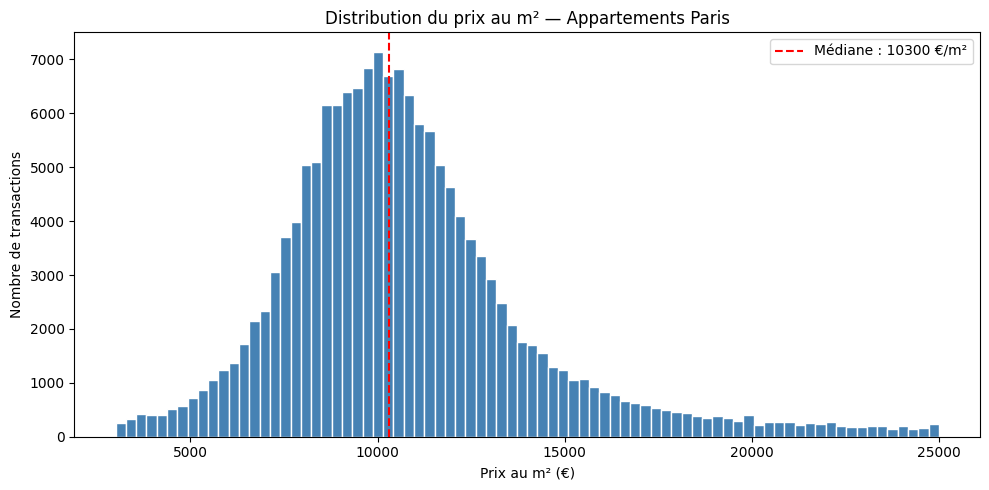

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean["prix_m2"], bins=80, color="steelblue", edgecolor="white")
ax.axvline(df_clean["prix_m2"].median(), color="red", linestyle="--", label=f"Médiane : {df_clean['prix_m2'].median():.0f} €/m²")
ax.set_xlabel("Prix au m² (€)")
ax.set_ylabel("Nombre de transactions")
ax.set_title("Distribution du prix au m² — Appartements Paris")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/hist_prix_m2.png", dpi=100)
plt.show()

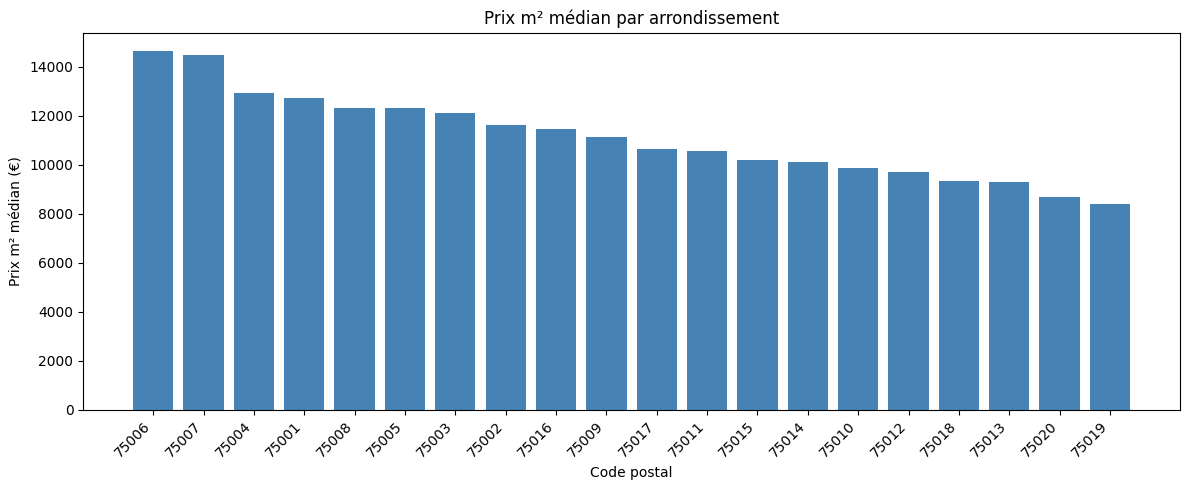

In [14]:
med_by_cp = df_clean.groupby("code_postal")["prix_m2"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(med_by_cp.index.astype(str), med_by_cp.values, color="steelblue")
ax.set_xlabel("Code postal")
ax.set_ylabel("Prix m² médian (€)")
ax.set_title("Prix m² médian par arrondissement")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../plots/bar_prix_m2_arrondissement.png", dpi=100)
plt.show()

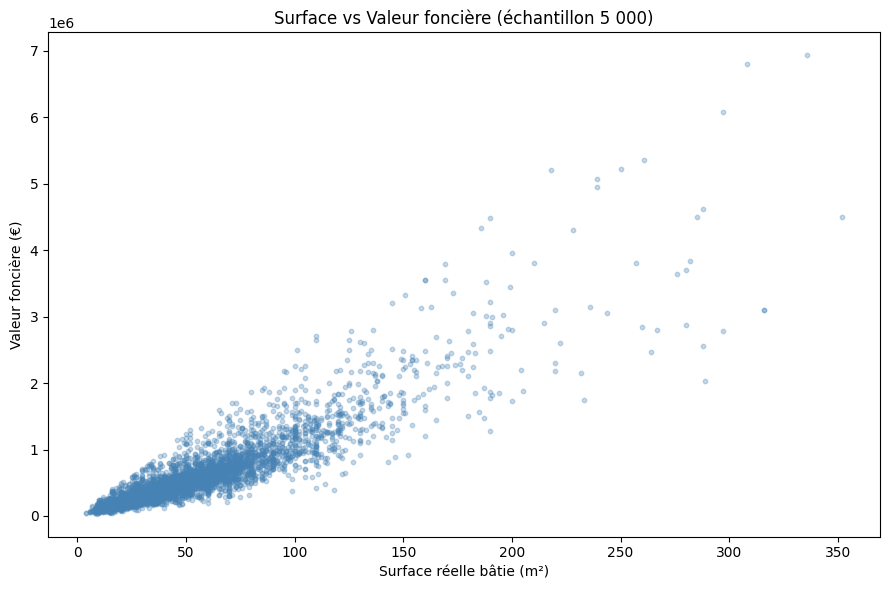

In [15]:
sample = df_clean.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample["surface_reelle_bati"], sample["valeur_fonciere"], alpha=0.3, s=10, color="steelblue")
ax.set_xlabel("Surface réelle bâtie (m²)")
ax.set_ylabel("Valeur foncière (€)")
ax.set_title("Surface vs Valeur foncière (échantillon 5 000)")
plt.tight_layout()
plt.savefig("../plots/scatter_surface_valeur.png", dpi=100)
plt.show()

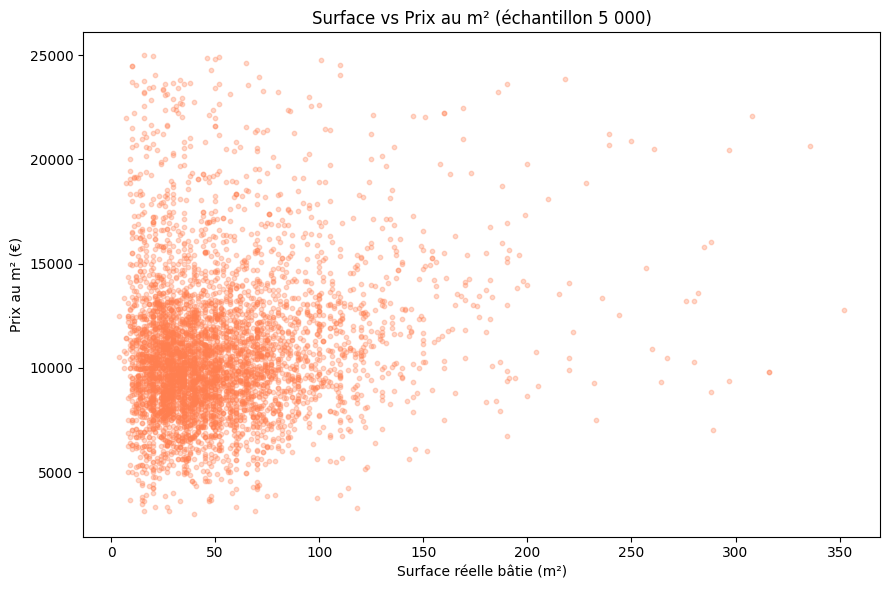

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample["surface_reelle_bati"], sample["prix_m2"], alpha=0.3, s=10, color="coral")
ax.set_xlabel("Surface réelle bâtie (m²)")
ax.set_ylabel("Prix au m² (€)")
ax.set_title("Surface vs Prix au m² (échantillon 5 000)")
plt.tight_layout()
plt.savefig("../plots/scatter_surface_prix_m2.png", dpi=100)
plt.show()

## 8. Sauvegarde du fichier nettoyé

In [17]:
df_clean.to_csv("../data/processed/dvf_paris_clean.csv", index=False)
print("Fichier sauvegardé : data/processed/dvf_paris_clean.csv")
print("Shape :", df_clean.shape)

Fichier sauvegardé : data/processed/dvf_paris_clean.csv
Shape : (156077, 42)
